In [1]:
import uuid
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

from metaopticsai.domain.design import MetalensDesignParams
from metaopticsai.physics.rcwa import sweep_diameter
from metaopticsai.physics.backends import default_registry
from metaopticsai.phase.profiles import fresnel_zone_lens, spiral_phase_plate
from metaopticsai.phase.quantization import quantize
from metaopticsai.analysis.psf import compute_psf
from metaopticsai.analysis.mtf import compute_mtf
from metaopticsai.analysis.strehl import compute_strehl_ratio
from metaopticsai.analysis.zernike import zernike_decomposition
from metaopticsai.optimization.heuristic import HeuristicOptimizer
from metaopticsai.physics.fdtd import FDTDStore
from metaopticsai.tools import build_tool_registry

In [2]:
class _Artifact:
    def __init__(self, payload: Any, metadata: dict):
        self.payload = payload
        self.metadata = metadata


class DictStore:
    """In-memory ArtifactStore satisfying the tool-layer Protocol."""

    def __init__(self):
        self._d: dict[str, tuple[str, Any, dict]] = {}

    def put(self, kind: str, payload: Any, **metadata: Any) -> str:
        h = f"{kind}-{uuid.uuid4().hex[:8]}"
        self._d[h] = (kind, payload, dict(metadata))
        return h

    def get(self, handle: str, *, expected_kind: str | None = None):
        kind, payload, meta = self._d[handle]
        if expected_kind is not None and kind != expected_kind:
            raise TypeError(f"handle {handle!r} is a {kind}, expected {expected_kind}")
        return _Artifact(payload, meta)

    def list(self, kind: str | None = None):
        return [h for h, (k, _, _) in self._d.items() if kind in (None, k)]


store = DictStore()
backends = default_registry()
print("registered backends:", backends.list_all())
print("available backends: ", backends.available())

registered backends: ['metabox', 'analytical', 's4']
available backends:  ['metabox', 'analytical']


In [3]:
params = MetalensDesignParams(
    wavelength_nm=532,
    focal_length_mm=2.0,
    diameter_mm=0.5,
    pillar_material="TiO2",
    pillar_height_nm=600,
    min_diameter_nm=80,
    max_diameter_nm=300,
    periodicity_nm=350,
)
print(f"NA         = {params.numerical_aperture:.3f}")
print(f"f/#        = {params.f_number:.2f}")
print(f"mean d     = {params.mean_diameter_nm:.0f} nm")
print(f"aspect     = {params.aspect_ratio:.2f}")

NA         = 0.124
f/#        = 4.00
mean d     = 190 nm
aspect     = 3.16


100%|██████████| 2/2 [00:02<00:00,  1.16s/it]


backend           = metabox
phase coverage    = 114.21%
mean transmission = 74.08%


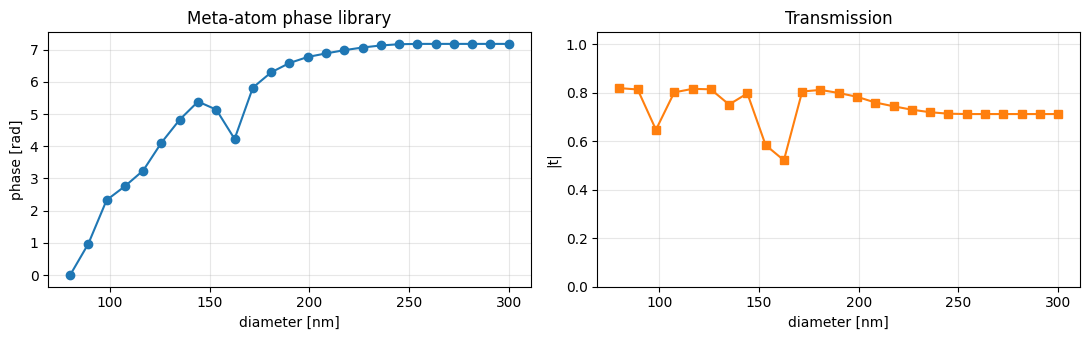

In [4]:
sweep = sweep_diameter(params, wavelength_nm=532, n=25)
print(f"backend           = {sweep.backend}")
print(f"phase coverage    = {sweep.phase_coverage:.2%}")
print(f"mean transmission = {sweep.mean_transmission:.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(sweep.sweep_values, sweep.phases_rad, "o-")
ax1.set(xlabel="diameter [nm]", ylabel="phase [rad]", title="Meta-atom phase library")
ax1.grid(alpha=0.3)
ax2.plot(sweep.sweep_values, sweep.amplitudes, "s-", color="tab:orange")
ax2.set(xlabel="diameter [nm]", ylabel="|t|", title="Transmission", ylim=(0, 1.05))
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Phase profile

The hyperbolic phase of a focusing metalens is

$$\varphi(r) = 2\pi - \frac{2\pi}{\lambda}\left(\sqrt{r^2 + f^2} - f\right) \bmod 2\pi.$$

phase mask shape: (1000, 1000)


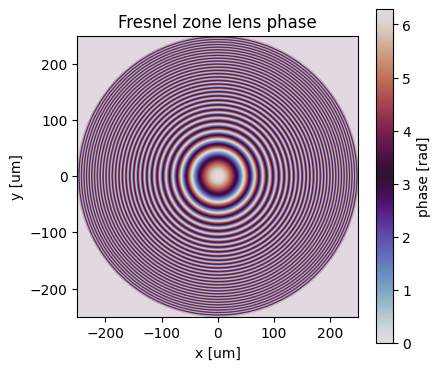

In [5]:
phi = fresnel_zone_lens(
    wavelength_nm=params.wavelength_nm,
    focal_length_um=params.focal_length_mm * 1000,
    diameter_um=params.diameter_mm * 1000,
    pixel_size_um=0.5,
)
print("phase mask shape:", phi.shape)

plt.figure(figsize=(4.5, 4))
plt.imshow(phi, cmap="twilight", extent=[-250, 250, -250, 250])
plt.colorbar(label="phase [rad]")
plt.title("Fresnel zone lens phase")
plt.xlabel("x [um]"); plt.ylabel("y [um]"); plt.tight_layout(); plt.show()

## 3. Analysis: PSF, MTF, Strehl, Zernike

Strehl ratio = 0.000   (Marechal criterion: >= 0.8)


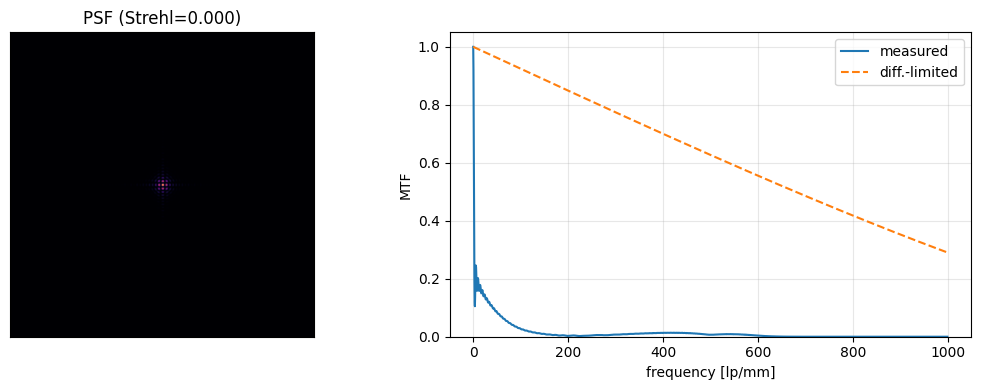

In [6]:
psf, x_um, y_um = compute_psf(
    phi, wavelength_nm=params.wavelength_nm,
    pixel_size_um=0.5,
    focal_length_um=params.focal_length_mm * 1000,
    pad_factor=4,
)
freqs, mtf_r, mtf_ideal = compute_mtf(
    psf, pixel_size_um=0.5,
    wavelength_nm=params.wavelength_nm,
    focal_length_um=params.focal_length_mm * 1000,
)
strehl, *_ = compute_strehl_ratio(phi, pad_factor=4)
print(f"Strehl ratio = {strehl:.3f}   (Marechal criterion: >= 0.8)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
N = psf.shape[0]; c = N // 2; w = N // 20
a1.imshow(psf[c-w:c+w, c-w:c+w], cmap="inferno")
a1.set_title(f"PSF (Strehl={strehl:.3f})"); a1.set_xticks([]); a1.set_yticks([])
a2.plot(freqs, mtf_r, label="measured")
a2.plot(freqs[: len(mtf_ideal)], mtf_ideal, "--", label="diff.-limited")
a2.set(xlabel="frequency [lp/mm]", ylabel="MTF", ylim=(0, 1.05)); a2.grid(alpha=0.3); a2.legend()
plt.tight_layout(); plt.show()

In [7]:
coeffs, names = zernike_decomposition(phi, n_terms=15)
top = sorted(coeffs.items(), key=lambda kv: abs(kv[1]), reverse=True)[:6]
print("Dominant Zernike aberrations:")
for j, c in top:
    print(f"  Z_{j:<2d}  {names[j]:24s}  {c:+7.3f} rad")

Dominant Zernike aberrations:
  Z_1   Piston                     +3.154 rad
  Z_4   Defocus                    -0.040 rad
  Z_11  Primary Spherical          +0.029 rad
  Z_14  Secondary Coma (v)         -0.009 rad
  Z_15  Secondary Coma (h)         -0.009 rad
  Z_7   Coma (vertical)            -0.008 rad


In [8]:
registry = build_tool_registry(store=store, backends=backends)
print(f"registered {len(registry)} tools:")
for name in registry.names():
    print("  -", name)

registered 15 tools:
  - get_fdtd_library
  - run_rcwa_sweep
  - list_materials
  - get_material_index
  - generate_phase_mask
  - analyze_psf
  - analyze_mtf
  - zernike_decompose
  - propagate_field
  - compute_max_intensity
  - compute_center_intensity
  - compute_mtf_volume
  - export_gds
  - optimize_metalens
  - list_artifacts


In [9]:
phase_tool = registry.get("generate_phase_mask")
phase_out = phase_tool.call_sync({
    "mask_type": "fzl",
    "wavelength_nm": 532,
    "focal_length_um": 2000,
    "diameter_um": 500,
    "pixel_size_um": 0.5,
    "circular": True,
})
print(phase_out)
phase_handle = phase_out["handle"]

{'handle': 'phase_mask-1317dc2a', 'shape': [1000, 1000], 'phase_min_rad': 0.0, 'phase_max_rad': 6.283184135802188, 'mask_type': 'fzl'}


In [10]:
psf_tool = registry.get("analyze_psf")
psf_out = psf_tool.call_sync({
    "mask_handle": phase_handle,
    "wavelength_nm": 532,
    "pixel_size_um": 0.5,
    "focal_length_um": 2000,
    "pad_factor": 4,
})
print("psf handle:", psf_out["handle"])
print(f"Strehl = {psf_out.get('strehl_ratio', float('nan')):.3f}")
print("handles currently in store:", registry.get("list_artifacts").call_sync({}))

psf handle: psf-b1d46cba
Strehl = 0.000
handles currently in store: ['phase_mask-1317dc2a', 'psf-b1d46cba']


## 5. Optimization (heuristic)

`HeuristicOptimizer` computes a closed-form Strehl estimate
$\mathcal{S}_\text{heur} = \bar A^2 \min(1, \Delta\phi/2\pi)$
directly from the pre-computed RCWA sweep — no search.

In [11]:
opt = HeuristicOptimizer()
_, fom, history = opt.optimize(
    params, target_fom=0.9, max_iters=5, sweep_result=sweep,
)
print(f"final Strehl estimate = {fom.value:.3f} (target 0.9)")
print(f"iterations run        = {fom.iteration}")
print(f"provenance            = backend={fom.backend}, method={fom.metadata.get('method')}")

final Strehl estimate = 0.549 (target 0.9)
iterations run        = 5
provenance            = backend=metabox, method=heuristic


## 6. Fabrication: quantize and export GDSII

Quantize the continuous phase to 8 levels, then map each level to a meta-atom dimension using the built-in FDTD library, and hand the layout to `GDSEngine`.

> Requires `gdsfactory`. The cell will raise a clear `ImportError` telling you how to install it if missing.

quantized levels present: [1, 2, 3, 4, 5, 6, 7, 8]
bin edges [deg]:          [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]


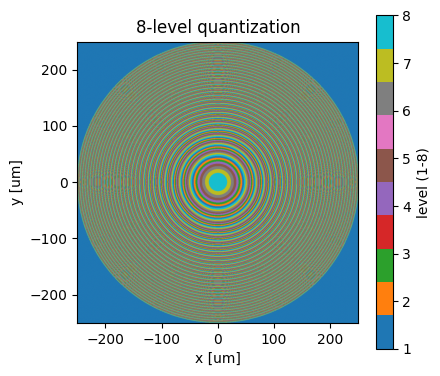

In [12]:
quant, bins = quantize(phi, n_levels=8)
print("quantized levels present:", sorted(np.unique(quant).tolist()))
print("bin edges [deg]:         ", [round(b, 1) for b in bins])

plt.figure(figsize=(4.5, 4))
plt.imshow(quant, cmap="tab10", extent=[-250, 250, -250, 250])
plt.colorbar(label="level (1-8)"); plt.title("8-level quantization")
plt.xlabel("x [um]"); plt.ylabel("y [um]"); plt.tight_layout(); plt.show()

In [13]:
from pathlib import Path
from metaopticsai.fabrication.gds import GDSEngine
from metaopticsai.configs.settings import settings

entry = FDTDStore().get(532)
out = settings.paths.output_dir / "metalens_tour_532nm.gds"

try:
    info = GDSEngine().generate(
        quantized_mask=quant, bins=bins,
        dimensions=entry.dimensions, phases=entry.phases,
        period=entry.period, pixel_size_um=0.5, unitcells_per_pixel=1,
        shape=entry.shape, is_circular=True,
        output_path=str(out),
        fin_width=entry.fin_width or 0.0,
        fin_length=entry.fin_length or 0.0,
    )
    print(f"GDS written: {info['filepath']}  ({info['file_size_kb']:.1f} kB, {info['time_seconds']:.2f} s)")
except ImportError as e:
    print("gdsfactory not installed:", e)

GDS written: D:\metacode\outputs\metalens_tour_532nm.gds  (23591.3 kB, 36.17 s)
